# SNN Model Evaluation & CNN Comparison
## DFUC2020 - Diabetic Foot Ulcer Detection

In [1]:
import sys
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from torch.utils.data import DataLoader, Dataset

project_path = r"D:\DFUC_Project"
if project_path not in sys.path:
    sys.path.append(project_path)

from src.dataset import DFUCDataset, load_annotations
from src.models.custom_cnn import CustomCNNDetector
from src.models.snn_cnn import SNNCNNDetector
from src.losses import DetectionLoss
from src.config import IMAGE_WIDTH, IMAGE_HEIGHT

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 1. Load Both Models

In [2]:
# Load CNN model
cnn_model = CustomCNNDetector()
cnn_model.load_state_dict(torch.load(
    r"D:\DFUC_Project\saved_models\custom_cnn_baseline.pth",
    map_location=device
))
cnn_model.to(device)
cnn_model.eval()
print(f"CNN model loaded: {sum(p.numel() for p in cnn_model.parameters()):,} params")

# Load SNN model
snn_model = SNNCNNDetector(num_steps=10, beta=0.9)
snn_model.load_state_dict(torch.load(
    r"D:\DFUC_Project\saved_models\snn_cnn_baseline.pth",
    map_location=device
))
snn_model.to(device)
snn_model.eval()
print(f"SNN model loaded: {sum(p.numel() for p in snn_model.parameters()):,} params")

CNN model loaded: 1,080,453 params
SNN model loaded: 94,341 params


## 2. Load Test Data (Labeled Test Images)

In [3]:
def load_test_labels(label_dir):
    """Parse YOLO-format .txt labels."""
    records = []
    for fname in sorted(os.listdir(label_dir)):
        if not fname.endswith('.txt'):
            continue
        img_id = int(fname.replace('.txt', ''))
        path = os.path.join(label_dir, fname)
        with open(path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    # YOLO: class x_center y_center width height (normalized)
                    xc, yc, w, h = map(float, parts[1:5])
                    xmin = (xc - w / 2) * IMAGE_WIDTH
                    ymin = (yc - h / 2) * IMAGE_HEIGHT
                    xmax = (xc + w / 2) * IMAGE_WIDTH
                    ymax = (yc + h / 2) * IMAGE_HEIGHT
                    records.append({
                        'filename': img_id,
                        'xmin': xmin, 'ymin': ymin,
                        'xmax': xmax, 'ymax': ymax
                    })
    return pd.DataFrame(records)

# Load training data (with ground truth)
train_annotations = load_annotations(
    r"D:\DFUC_Project\Dataset\DFUC2020\DFUC_Training_Set\groundtruth.csv"
)
val_split = pd.read_csv(
    r"D:\DFUC_Project\Dataset\DFUC2020\DFUC_Training_Set\val_split.csv"
)

# Filter to validation set only
val_annotations = train_annotations[train_annotations['filename'].isin(val_split['filename'])]

val_image_path = r"D:\DFUC_Project\Dataset\DFUC2020\DFUC_Training_Set\images"
print(f"Validation samples: {val_annotations['filename'].nunique()}")
print(f"Validation annotations: {len(val_annotations)}")

Validation samples: 200
Validation annotations: 239


## 3. Inference Function for Both Models

In [4]:
import time
from src.preprocessing import resize_image, normalize_image, apply_clahe, apply_bilateral_filter

def preprocess_image(img_path):
    """Load and preprocess a single image."""
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    orig_h, orig_w = img.shape[:2]
    
    img = resize_image(img)
    img = normalize_image(img)
    img = (img * 255).astype(np.uint8)
    img = apply_clahe(img)
    img = apply_bilateral_filter(img)
    
    tensor = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
    return tensor, (orig_w, orig_h)


def run_inference(model, image_tensor, model_type='cnn'):
    """Run model inference and return [B, 5] output (sigmoided).
    Both models now return a single [B, 5] = [obj, x1, y1, x2, y2] tensor.
    """
    with torch.no_grad():
        output = model(image_tensor.unsqueeze(0).to(device))
    
    return torch.sigmoid(output).squeeze(0).cpu().numpy()


def decode_output(pred, orig_size):
    """Convert normalized [obj, x1, y1, x2, y2] to pixel coords."""
    orig_w, orig_h = orig_size
    obj_score = float(pred[0])
    x1 = pred[1] * orig_w
    y1 = pred[2] * orig_h
    x2 = pred[3] * orig_w
    y2 = pred[4] * orig_h
    return obj_score, x1, y1, x2, y2


def compute_iou(box_a, box_b):
    """Compute IoU between two boxes [x1, y1, x2, y2]."""
    x1 = max(box_a[0], box_b[0])
    y1 = max(box_a[1], box_b[1])
    x2 = min(box_a[2], box_b[2])
    y2 = min(box_a[3], box_b[3])
    
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])
    union = area_a + area_b - inter
    
    return inter / union if union > 0 else 0.0

## 4. Evaluate Both Models on Validation Set

In [5]:
def evaluate_models(cnn_model, snn_model, annotations, image_folder, threshold=0.5):
    """
    Evaluate both models on the same images.
    Preprocesses each image ONCE and reuses it for both models.
    """
    results = []
    img_ids = sorted(annotations['filename'].unique())
    total = len(img_ids)
    
    for idx, img_id in enumerate(img_ids):
        gt_boxes = annotations[annotations['filename'] == img_id]
        img_path = os.path.join(image_folder, f"{img_id}.jpg")
        
        if not os.path.exists(img_path):
            continue
        
        # Preprocess ONCE (the slow part)
        tensor, orig_size = preprocess_image(img_path)
        
        # Run both models on the same tensor
        cnn_pred = run_inference(cnn_model, tensor, 'cnn')
        snn_pred = run_inference(snn_model, tensor, 'snn')
        
        for model_name, pred in [('cnn', cnn_pred), ('snn', snn_pred)]:
            obj_score, px1, py1, px2, py2 = decode_output(pred, orig_size)
            
            # Best IoU against all GT boxes
            best_iou = 0.0
            best_gt = None
            for _, gt in gt_boxes.iterrows():
                gt_box = [gt['xmin'], gt['ymin'], gt['xmax'], gt['ymax']]
                iou = compute_iou([px1, py1, px2, py2], gt_box)
                if iou > best_iou:
                    best_iou = iou
                    best_gt = gt_box
            
            results.append({
                'model': model_name,
                'image_id': img_id,
                'has_ulcer': len(gt_boxes) > 0,
                'detected': obj_score > threshold,
                'confidence': obj_score,
                'best_iou': best_iou,
                'pred_box': [px1, py1, px2, py2],
                'gt_box': best_gt
            })
        
        if (idx + 1) % 25 == 0:
            print(f"  {idx+1}/{total} images processed")
    
    return pd.DataFrame(results)


print("Evaluating CNN + SNN on validation set (image preprocessed once)...")
start = time.time()
all_results = evaluate_models(cnn_model, snn_model, val_annotations, val_image_path)
elapsed = time.time() - start
print(f"Done in {elapsed:.1f}s")

cnn_results = all_results[all_results['model'] == 'cnn'].copy()
snn_results = all_results[all_results['model'] == 'snn'].copy()
print(f"CNN evaluated: {len(cnn_results)} images")
print(f"SNN evaluated: {len(snn_results)} images")

Evaluating CNN + SNN on validation set (image preprocessed once)...
  25/200 images processed
  50/200 images processed
  75/200 images processed
  100/200 images processed
  125/200 images processed
  150/200 images processed
  175/200 images processed
  200/200 images processed
Done in 24.2s
CNN evaluated: 200 images
SNN evaluated: 200 images


## 5. Compute Metrics

In [6]:
def compute_metrics(df, threshold=0.5):
    """Compute detection metrics."""
    tp = len(df[(df['has_ulcer']) & (df['detected'])])
    fp = len(df[(~df['has_ulcer']) & (df['detected'])])
    fn = len(df[(df['has_ulcer']) & (~df['detected'])])
    tn = len(df[(~df['has_ulcer']) & (~df['detected'])])
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    accuracy = (tp + tn) / len(df) if len(df) > 0 else 0.0
    
    iou_scores = df[df['has_ulcer']]['best_iou']
    mean_iou = iou_scores.mean() if len(iou_scores) > 0 else 0.0
    
    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'accuracy': accuracy,
        'mean_iou': mean_iou,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'total': len(df)
    }


cnn_metrics = compute_metrics(cnn_results)
snn_metrics = compute_metrics(snn_results)

metrics_df = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1-Score', 'Accuracy', 'Mean IoU',
               'True Pos.', 'False Pos.', 'False Neg.', 'True Neg.', 'Total'],
    'CNN': [
        f"{cnn_metrics['precision']:.3f}",
        f"{cnn_metrics['recall']:.3f}",
        f"{cnn_metrics['f1']:.3f}",
        f"{cnn_metrics['accuracy']:.3f}",
        f"{cnn_metrics['mean_iou']:.3f}",
        cnn_metrics['tp'], cnn_metrics['fp'],
        cnn_metrics['fn'], cnn_metrics['tn'],
        cnn_metrics['total']
    ],
    'SNN': [
        f"{snn_metrics['precision']:.3f}",
        f"{snn_metrics['recall']:.3f}",
        f"{snn_metrics['f1']:.3f}",
        f"{snn_metrics['accuracy']:.3f}",
        f"{snn_metrics['mean_iou']:.3f}",
        snn_metrics['tp'], snn_metrics['fp'],
        snn_metrics['fn'], snn_metrics['tn'],
        snn_metrics['total']
    ]
})

print("=" * 60)
print("MODEL COMPARISON METRICS")
print("=" * 60)
print(metrics_df.to_string(index=False))

# Save metrics
metrics_df.to_csv(r"D:\DFUC_Project\results\comparison_metrics.csv", index=False)
print("\nMetrics saved to results/comparison_metrics.csv")

MODEL COMPARISON METRICS
    Metric   CNN   SNN
 Precision 1.000 1.000
    Recall 1.000 1.000
  F1-Score 1.000 1.000
  Accuracy 1.000 1.000
  Mean IoU 0.506 0.226
 True Pos.   200   200
False Pos.     0     0
False Neg.     0     0
 True Neg.     0     0
     Total   200   200

Metrics saved to results/comparison_metrics.csv


## 6. Visual Comparison: Bar Charts

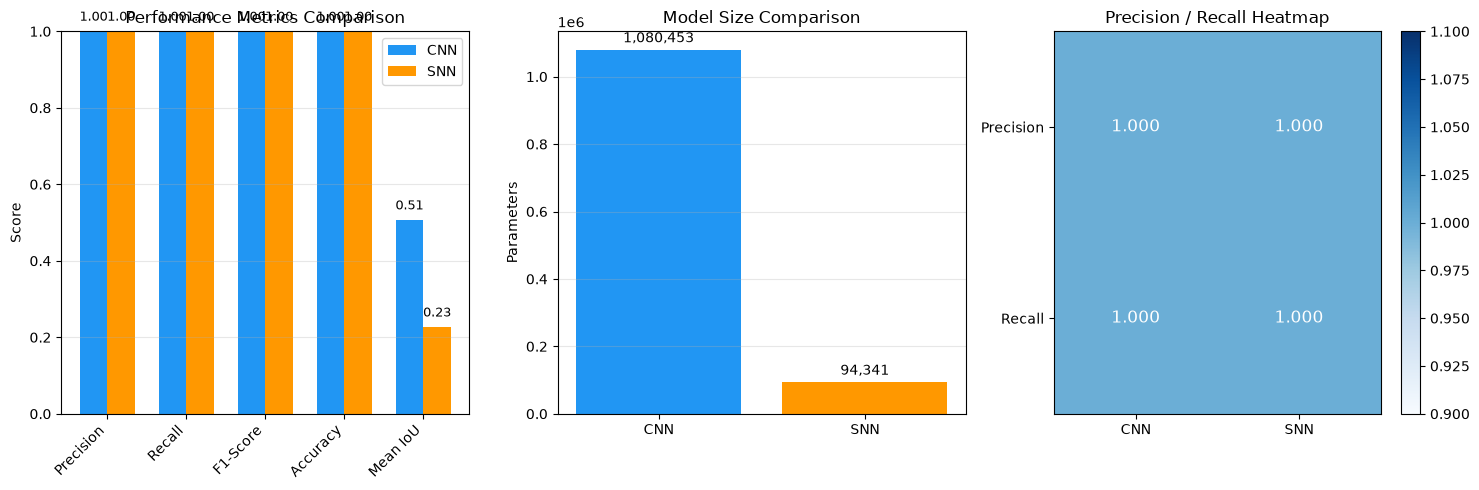

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics_names = ['Precision', 'Recall', 'F1-Score', 'Accuracy', 'Mean IoU']
metric_keys = ['precision', 'recall', 'f1', 'accuracy', 'mean_iou']
cnn_vals = [cnn_metrics[k] for k in metric_keys]
snn_vals = [snn_metrics[k] for k in metric_keys]

x = np.arange(len(metrics_names))
width = 0.35

axes[0].bar(x - width/2, cnn_vals, width, label='CNN', color='#2196F3')
axes[0].bar(x + width/2, snn_vals, width, label='SNN', color='#FF9800')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_names, rotation=45, ha='right')
axes[0].set_ylabel('Score')
axes[0].set_title('Performance Metrics Comparison')
axes[0].legend()
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(cnn_vals):
    axes[0].text(i - width/2, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=9)
for i, v in enumerate(snn_vals):
    axes[0].text(i + width/2, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

# Parameter count comparison
cnn_params = sum(p.numel() for p in cnn_model.parameters())
snn_params = sum(p.numel() for p in snn_model.parameters())

axes[1].bar(['CNN', 'SNN'], [cnn_params, snn_params], color=['#2196F3', '#FF9800'])
axes[1].set_ylabel('Parameters')
axes[1].set_title('Model Size Comparison')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate([cnn_params, snn_params]):
    axes[1].text(i, v + max(cnn_params, snn_params)*0.02, f'{v:,}', ha='center', fontsize=10)

# Confusion matrix
cnn_cm = np.array([[cnn_metrics['tn'], cnn_metrics['fp']],
                   [cnn_metrics['fn'], cnn_metrics['tp']]])
snn_cm = np.array([[snn_metrics['tn'], snn_metrics['fp']],
                   [snn_metrics['fn'], snn_metrics['tp']]])

im = axes[2].imshow(np.array([[cnn_metrics['precision'], snn_metrics['precision']],
                              [cnn_metrics['recall'], snn_metrics['recall']]]),
                    cmap='Blues', aspect='auto')
axes[2].set_xticks([0, 1])
axes[2].set_yticks([0, 1])
axes[2].set_xticklabels(['CNN', 'SNN'])
axes[2].set_yticklabels(['Precision', 'Recall'])
axes[2].set_title('Precision / Recall Heatmap')
for i in range(2):
    for j in range(2):
        val = cnn_vals[0] if i == 0 and j == 0 else \
              snn_vals[0] if i == 0 and j == 1 else \
              cnn_vals[1] if i == 1 and j == 0 else snn_vals[1]
        axes[2].text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=12, 
                     color='white' if val > 0.5 else 'black')
fig.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.savefig(r"D:\DFUC_Project\results\comparison_charts.png", dpi=150, bbox_inches='tight')
plt.show()

## 7. Sample Prediction Visualizations

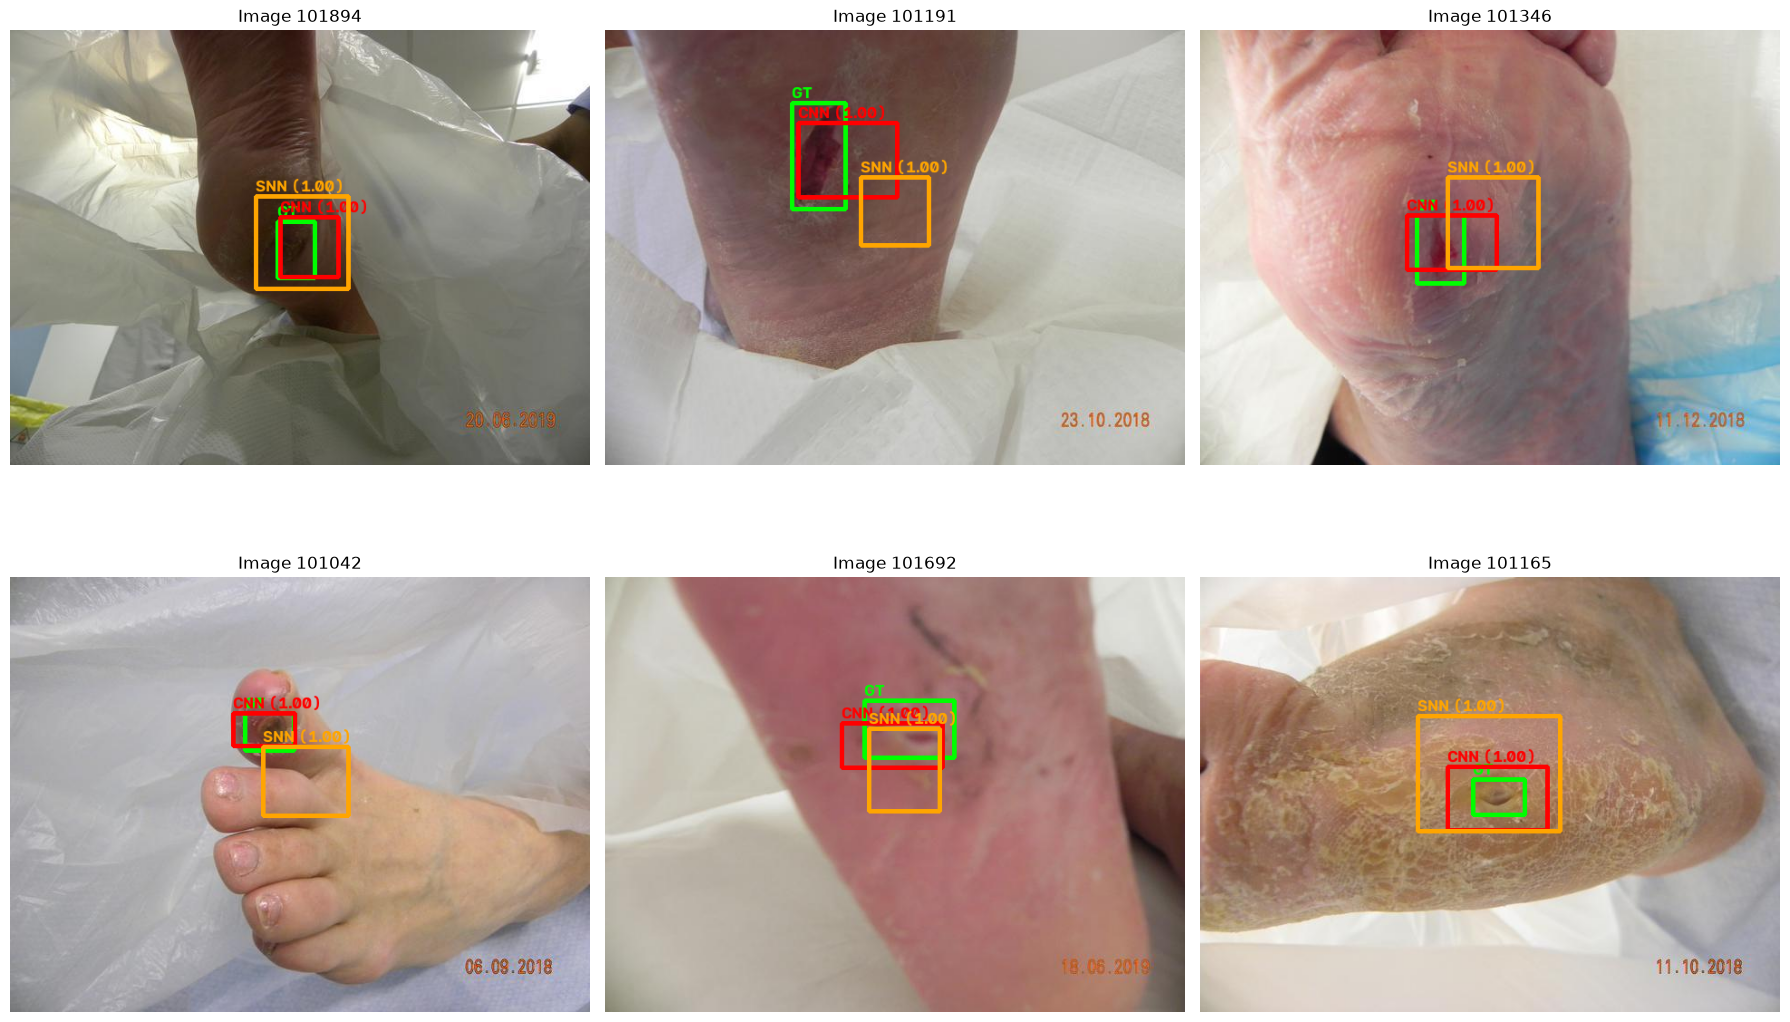

In [8]:
def draw_box(img, box, color, label=''):
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)
    if label:
        cv2.putText(img, label, (x1, max(y1-5, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    return img

# Show 6 sample predictions side by side
sample_ids = np.random.choice(cnn_results['image_id'].values, 
                              min(6, len(cnn_results)), replace=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, img_id in enumerate(sample_ids):
    img_path = os.path.join(val_image_path, f"{img_id}.jpg")
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Ground truth
    gt = val_annotations[val_annotations['filename'] == img_id]
    if len(gt) > 0:
        img = draw_box(img.copy(), 
                       [gt.iloc[0]['xmin'], gt.iloc[0]['ymin'],
                        gt.iloc[0]['xmax'], gt.iloc[0]['ymax']],
                       (0, 255, 0), 'GT')
    
    # CNN prediction
    cnn_row = cnn_results[cnn_results['image_id'] == img_id]
    if len(cnn_row) > 0 and cnn_row.iloc[0]['detected']:
        pb = cnn_row.iloc[0]['pred_box']
        img = draw_box(img, pb, (255, 0, 0), f"CNN ({cnn_row.iloc[0]['confidence']:.2f})")
    
    # SNN prediction
    snn_row = snn_results[snn_results['image_id'] == img_id]
    if len(snn_row) > 0 and snn_row.iloc[0]['detected']:
        pb = snn_row.iloc[0]['pred_box']
        img = draw_box(img, pb, (255, 165, 0), f"SNN ({snn_row.iloc[0]['confidence']:.2f})")
    
    axes[idx].imshow(img)
    axes[idx].set_title(f'Image {img_id}', fontsize=12)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(r"D:\DFUC_Project\results\prediction_samples.png", dpi=150, bbox_inches='tight')
plt.show()

## 8. IoU Distribution Comparison

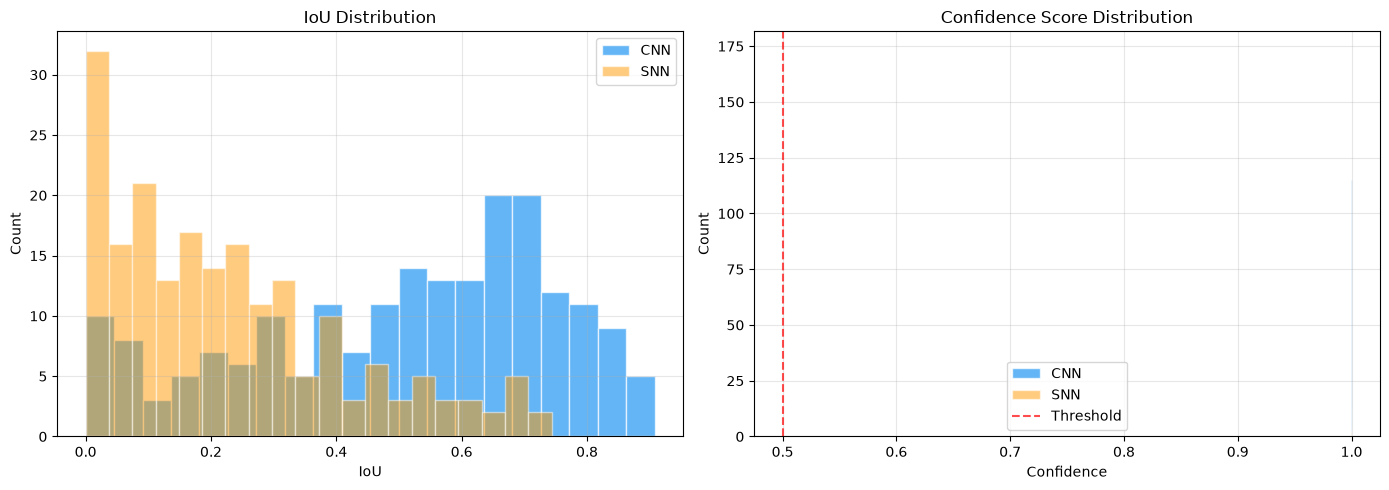

CNN  - Mean IoU: 0.506, Median IoU: 0.546
SNN  - Mean IoU: 0.226, Median IoU: 0.187

CNN  - Mean Confidence: 1.000
SNN  - Mean Confidence: 1.000


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cnn_iou = cnn_results[cnn_results['has_ulcer']]['best_iou']
snn_iou = snn_results[snn_results['has_ulcer']]['best_iou']

axes[0].hist(cnn_iou, bins=20, alpha=0.7, color='#2196F3', edgecolor='white', label='CNN')
axes[0].hist(snn_iou, bins=20, alpha=0.5, color='#FF9800', edgecolor='white', label='SNN')
axes[0].set_xlabel('IoU')
axes[0].set_ylabel('Count')
axes[0].set_title('IoU Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Confidence distribution
axes[1].hist(cnn_results['confidence'], bins=20, alpha=0.7, 
             color='#2196F3', edgecolor='white', label='CNN')
axes[1].hist(snn_results['confidence'], bins=20, alpha=0.5,
             color='#FF9800', edgecolor='white', label='SNN')
axes[1].axvline(0.5, color='red', linestyle='--', alpha=0.7, label='Threshold')
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Count')
axes[1].set_title('Confidence Score Distribution')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(r"D:\DFUC_Project\results\iou_confidence_dist.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"CNN  - Mean IoU: {cnn_iou.mean():.3f}, Median IoU: {cnn_iou.median():.3f}")
print(f"SNN  - Mean IoU: {snn_iou.mean():.3f}, Median IoU: {snn_iou.median():.3f}")
print(f"\nCNN  - Mean Confidence: {cnn_results['confidence'].mean():.3f}")
print(f"SNN  - Mean Confidence: {snn_results['confidence'].mean():.3f}")